# Playbook Workshop 2: Parts 5 to 9 (venv-data)

Markdown parts, code cells, interpretation under each cell; kernel **Python (venv-data)**. "Manual Step" cells automatically create the files that learners create in the Explorer.

# PART 5: THE SECOND VIRTUAL ENVIRONMENT

Parts 1 to 4 shot in`.venv-base`(Python pure, NumPy). The following parts (pandas, graphs) live in a separate ** environment**,`.venv-data`. This part shows why.

## Create`.venv-data`

Open a **second** terminal in`python_fabric_training`(The first one runs Jupyter, we don't stop him).

```powershell
py -m venv .venv-data
.venv-data\Scripts\activate.bat
py -m pip install --upgrade pip
py -m pip install pandas matplotlib seaborn pyarrow ipykernel
py -m pip freeze > requirements-data.txt
py -m ipykernel install --user --name venv-data --display-name "Python (venv-data)"
```

```text
Installed kernelspec venv-data in C:\Users\formation\AppData\Roaming\jupyter\kernels\venv-data
```

| Paquet       | Role                                                                          |
| ------------ | ----------------------------------------------------------------------------- |
| `pandas`     | Data tables (DataFrame); install **NumPy** with him                 |
| `matplotlib` | Graphiques de base                                                            |
| `seaborn`    | Statistical graphs, built on matplotlib and pandas                  |
| `pyarrow`    | Reading and writing **Parquet** (Manric's)                   |
| `ipykernel`  | Allows Jupyter to use this environment as **core**                 |

**What you need to see on screen**:

- the prompt of the second terminal prefixed by`(.venv-data)`
- `requirements-data.txt`created (net longer than`requirements-base.txt`)
- message`Installed kernelspec venv-data ...`

## Four-step demonstration

**Time 1: stay in`venv-base`* Notebook`workshop2`still uses the kernel **Python (venv-base)**. Run Cells 32 and 33 below: pandas cannot be found.

**Time 2: go to`venv-data`.**

- Reload the notebook page (F5) if`venv-data`does not appear in the list.
- Menu **Kernel → Change kernel → Python (venv-data)**.
- Re-executing Cells 32 and 33: everything is present.

**Time 3: Return to`venv-base`.** **Kernel → Change kernel → Python (venv-base)**, then re-executing Cell 33: the error ** returns**. Libraries have not disappeared: they have never been in this environment.

**Time 4: start again on`venv-data`** for the entire workshop suite.

| Situation                                    | Result of`import pandas`     |
| -------------------------------------------- | ------------------------------- |
| Noyau **venv-base**                          | `ModuleNotFoundError`           |
| Noyau **venv-data**                          | Fonctionne                      |
| Return to **venv-base**                     | `ModuleNotFoundError`again |

> All cells in Parts 6 to 9 reload their data for this reason.

> **The same principle in Fabric**: two **Environments** may contain different libraries, and each notebook chooses its own. A notebook without the proper environment fails with the same`ModuleNotFoundError`.

## Cell 32: Control of available libraries

In [1]:
# === CELLULE 32 : Ce que voit le noyau actif ===
import importlib.metadata as metadata      # versions des paquets installés
import sys
from importlib.util import find_spec       # teste la présence d'un paquet sans l'importer

# --- 1. Quel Python exécute cette cellule ?
print("Interpréteur :", sys.executable)

# --- 2. Pour chaque paquet : absent, ou sa version
for nom in ("numpy", "pandas", "matplotlib", "seaborn", "pyarrow"):
    if find_spec(nom) is None:                        # None = introuvable dans cet environnement
        print(f"{nom:<11} ABSENT")
    else:
        print(f"{nom:<11} {metadata.version(nom)}")

Interpréteur : C:\Users\DELL\AppData\Local\Programs\Python\Python313\python.exe
numpy       2.2.6
pandas      2.3.3
matplotlib  3.11.2
seaborn     0.13.2
pyarrow     23.0.0


### Interpretation: Cell 32, Control of Available Libraries

- **Noyau `venv-base`** : NumPy is present; pandas, matplotlib, seaborn and pyarrow are **absent**.
- **Same machine, same file**: the**environment** decides, not the post.
- **Continued**: the following cell shows the error that a`import pandas`.

## Cell 33: Import Pandas: Error, then Success

In [2]:
# === CELLULE 33 : Importer les bibliothèques de données ===
import numpy as np                       # calcul sur tableaux
import pandas as pd                      # tableaux de données (DataFrame)
import matplotlib                        # graphiques : bibliothèque de base
import matplotlib.pyplot as plt          # son interface de dessin
import seaborn as sns                    # graphiques statistiques

print("pandas", pd.__version__, "| matplotlib", matplotlib.__version__, "| seaborn", sns.__version__)

pandas 2.3.3 | matplotlib 3.11.2 | seaborn 0.13.2


### Interpretation: Cell 33, Import Pandas: Error, then Success

- **In`venv-base`** : `ModuleNotFoundError: No module named 'pandas'`. The code is correct, the environment is incomplete.
- **In`venv-data`**: versions are displayed.
- ** Bad reflex**: throw`pip install pandas`in`venv-base`; We'd lose the separation.
- **Good reflex**: choose the right kernel, and check`sys.executable`.

## Cell 34: Read CSV file with`read_csv`

In [3]:
# === CELLULE 34 : read_csv ===
from pathlib import Path

df = pd.read_csv("data/consommation_30jours.csv", encoding="utf-8-sig")   # lecture, BOM retiré
print(df.shape)                       # (nombre de lignes, nombre de colonnes)
print(df.columns.tolist())            # noms des colonnes
print(df.head(4))                     # aperçu des 4 premières lignes

(4365, 6)
['timestamp', 'site_id', 'consumption_mw', 'voltage_v', 'frequency_hz', 'status']
             timestamp       site_id  consumption_mw  voltage_v  frequency_hz  \
0  2025-01-30T03:00:00  SITE_COM_001           0.479      223.3         50.02   
1  2025-01-08 18:00:00  SITE_COM_001           1.288      229.1         49.95   
2  2025-01-30T16:00:00  SITE_COM_001           1.218      233.6         49.96   
3  2025-01-12T17:00:00  SITE_COM_002           0.672      230.2         49.83   

  status  
0     OK  
1     OK  
2     OK  
3     OK  


### Interpretation: Cell 34, Read CSV file with`read_csv`

- **`(4365, 6)`**: 4,365 rows, 6 columns.
- **Types deducted**:`consumption_mw`is in`float64`(the voids become`NaN`) ; with the module`csv`everything remained of the text.
- **`timestamp`still in text**: three mixed formats, to be converted (Part 6).
- **`encoding="utf-8-sig"`**: to be reported systematically for Windows CSV.

## 📝 Cellule 35 : Explorer : `info`, `dtypes`, `describe`

In [4]:
# === CELLULE 35 : Explorer le DataFrame ===
df.info()                                              # structure du tableau
print()
print(df["consumption_mw"].describe().round(3))        # statistiques de la colonne de consommation
print(df["status"].value_counts())                     # répartition des statuts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4365 entries, 0 to 4364
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   timestamp       4365 non-null   object 
 1   site_id         4365 non-null   object 
 2   consumption_mw  4275 non-null   float64
 3   voltage_v       4365 non-null   float64
 4   frequency_hz    4365 non-null   float64
 5   status          4365 non-null   object 
dtypes: float64(3), object(3)
memory usage: 204.7+ KB

count    4275.000
mean      -54.830
std       219.226
min      -999.000
25%         0.324
50%         0.531
75%         1.326
max         5.846
Name: consumption_mw, dtype: float64
status
OK       4012
ERROR     353
Name: count, dtype: int64


### Interpretation: Cell 35, Explorer:`info`, `dtypes`, `describe`

- **`consumption_mw`**: 4,275 non-zero values on 4,365, thus **90 empty**.
- **Type `str`**: Since pandas 3, the text columns have this type; in pandas 2.x, it was`object`.
- **Distorted statistics**: minimum`-999`and medium`-54,8`** error codes** are counted as measurements.
- **`status`** : 353 lines`ERROR`(including doubles).

## 📝 Cellule 36 : `Series`, `loc`and`iloc`

In [5]:
# === CELLULE 36 : Séries, loc et iloc ===
s = df["consumption_mw"]                              # une colonne = une Series
print(type(s).__name__, s.dtype, len(s))              # type de l'objet, type des valeurs, nombre de valeurs

print(df.loc[0, "site_id"], "|", df.iloc[0, 1])       # même case : par étiquette, puis par position
print(df.iloc[0:3, 1:3])                              # lignes 0 à 2, colonnes 1 et 2
print(df.loc[df["site_id"] == "SITE_IND_001", "consumption_mw"].head(3).tolist())   # masque + colonne

# Les mêmes syntaxes que sur le Tableau de la Partie 3
print(len(df), "site_id" in df, list(df)[:3])         # __len__, __contains__, __iter__ (noms de colonnes)
print(df.site_id.equals(df["site_id"]))               # __getattr__ : df.site_id est df["site_id"]

Series float64 4365
SITE_COM_001 | SITE_COM_001
        site_id  consumption_mw
0  SITE_COM_001           0.479
1  SITE_COM_001           1.288
2  SITE_COM_001           1.218
[2.874, 1.769, 1.595]
4365 True ['timestamp', 'site_id', 'consumption_mw']
True


### Interpretation: Cell 36,`Series`, `loc`and`iloc`

- **`type` = `Series`**: one column, 4,365 values`float64`.
- **`loc`and`iloc`**: label`0`and position`0`coincide here, because the index is`0, 1, 2…`.
- **Tranche `iloc[0:3, 1:3]`**: end-point **excluded**; with`loc`, the end point is **included**.
- **`loc[masque, "colonne"]`**: Standard form to read a subset.
- **`4365 True ['timestamp', 'site_id', 'consumption_mw']`**:`len`,`in`and`list(df)`behave as on the`Tableau`.
- **`True`** : `df.site_id`and`df["site_id"]`designate the same column.

## 📝 Cellule 37 : Filtrer : masques, `isin`, `between`, `query`

In [5]:
# === CELLULE 37 : Filtres ===
fort = df[df["consumption_mw"] > 3.5]                 # lignes au-dessus de 3,5 MW
print(len(fort), fort["site_id"].unique().tolist())   # combien, et de quels sites

# Deux conditions : parenthèses obligatoires autour de chacune
masque = (df["site_id"] == "SITE_IND_002") & (df["consumption_mw"] > 3.5)
print(masque.sum())                                   # True compte pour 1

print(df["site_id"].isin(["SITE_RES_001", "SITE_RES_002"]).sum())   # lignes des deux sites résidentiels
print(df["consumption_mw"].between(1, 2).sum())                     # mesures entre 1 et 2 MW

# La même sélection que « masque », écrite avec query
print(len(df.query("site_id == 'SITE_IND_002' and consumption_mw > 3.5")))

6 ['SITE_COM_001', 'SITE_IND_002']
5
1454
1064
5


### Interpretation: Cell 37, Filter: masks,`isin`, `between`, `query`

- **6 values > 3.5 MW**: peaks of`SITE_COM_001`(capacity 2 MW) and`SITE_IND_002`.
- **Required parenthesis** around each condition with`&`and `|`.
- **`isin`** : 1,454 residential lines; **`between`** : ** inclusive** terminals by default.
- **`query`**: same result (5 lines), more legible for simple conditions.

## 📝 Cellule 38 : Nouvelles colonnes : `assign`, `rename`, independent copy

In [6]:
# === CELLULE 38 : Colonnes, renommage, Copy-on-Write ===

# --- 1. Renommer une colonne (nom plus court)
df = df.rename(columns={"consumption_mw": "conso_mw"})

# --- 2. Ajouter une colonne « famille » : le 2e morceau de site_id (SITE_IND_001 -> IND)
df = df.assign(famille=lambda d: d["site_id"].str.split("_").str[1])      # d = le DataFrame en cours
print(df["famille"].value_counts().to_dict())

# --- 3. Copy-on-Write : on ajoute une colonne à un DataFrame dérivé ; l'original reste intact
sous = df[df["site_id"] == "SITE_IND_001"]                                # un sous-ensemble
sous = sous.assign(conso_kw=sous["conso_mw"] * 1000)                      # nouvelle colonne, en kW
print("colonne conso_kw dans df :", "conso_kw" in df.columns, "| dans sous :", "conso_kw" in sous.columns)

# --- 4. Modifier des lignes précises : ici, aucune valeur ne dépasse 100
df.loc[df["conso_mw"] > 100, "conso_mw"] = np.nan
print(df["conso_mw"].max())

{'COM': 1457, 'RES': 1454, 'IND': 1454}
colonne conso_kw dans df : False | dans sous : True
5.846


### Interpretation: Cell 38, New Columns:`assign`, `rename`, independent copy

- **`assign`**: returns a **new** DataFrame, without changing the old.
- **Copy-on-Write (pandas 3)** : `conso_kw`exists only in`sous`Never in`df`.
- **Before pandas 3**: writing in a subset could modify the original or lift`SettingWithCopyWarning`.
- **`.loc[masque, "col"] = valeur`**: the correct writing; There is no more than 100 lines here. **Avoid`inplace`**

## 📝 Cellule 39 : Types : `astype`, `category`, `to_numeric`

In [7]:
# === CELLULE 39 : Types et mémoire ===

# --- 1. Convertir en « category » les colonnes à peu de valeurs distinctes, et mesurer le gain
avant = df.memory_usage(deep=True).sum()                 # mémoire avant conversion (textes compris)
df["site_id"] = df["site_id"].astype("category")         # 6 valeurs distinctes sur 4 365 lignes
df["famille"] = df["famille"].astype("category")         # 3 valeurs distinctes
apres = df.memory_usage(deep=True).sum()                 # mémoire après conversion
print(f"{avant / 1024:.0f} Ko -> {apres / 1024:.0f} Ko")
print(df.dtypes)                                         # les nouveaux types

# --- 2. Convertir du texte en nombres : ce qui est illisible devient NaN au lieu de faire échouer
texte = pd.Series(["0.865", "abc", "", "1.2"])
print(pd.to_numeric(texte, errors="coerce").tolist())

1092 Ko -> 620 Ko
timestamp         object
site_id         category
conso_mw         float64
voltage_v        float64
frequency_hz     float64
status            object
famille         category
dtype: object
[0.865, nan, nan, 1.2]


### Interpretation: Cell 39, Types:`astype`, `category`, `to_numeric`

- **Approximately 570 KB → 270 KB** (the exact value varies according to the Python version):`category`stores the 6 values once, then complete codes.
- **To be reserved** for columns with few separate values.
- **`to_numeric(errors="coerce")`** : `'abc'`and`''` deviennent `NaN`instead of failing conversion.

# PART 6: DATA QUALITY WITH PANDAS

## Cell 40: Error codes:`isin`,`mask`,`replace`

In [8]:
# === CELLULE 40 : Codes erreur en NaN ===
CODES = [-999, -888, -777]

# Compter avant de nettoyer
print(df["conso_mw"].isin(CODES).sum(), "codes erreur")
print(df.loc[df["conso_mw"].isin(CODES), "conso_mw"].value_counts().to_dict())

# Deux écritures du même nettoyage
nettoye = df["conso_mw"].mask(df["conso_mw"].isin(CODES))     # NaN là où la valeur est un code
equivalent = df["conso_mw"].replace(CODES, np.nan)            # remplace chaque code par NaN
print(nettoye.isna().sum(), nettoye.equals(equivalent))       # nombre de NaN, résultats identiques ?
print(nettoye.min(), nettoye.max())                           # plus aucune valeur négative

263 codes erreur
{-999.0: 111, -888.0: 85, -777.0: 67}
353 True
0.216 5.846


### Interpretation: Cell 40, Error Codes:`isin`, `mask`, `replace`

- **263 lines** with code:`-999` × 111, `-888` × 85, `-777` × 67 (doublons compris).
- **`mask`and`replace`**: identical results (`True`) ; 353 `NaN` = 263 codes + 90 vides.
- **After cleaning**: minimum 0.216; no negative value.
- **Maximum 5.846** remains an aberrant peak: it will be treated by the load rate.

## 📝 Cellule 41 : Doublons : `duplicated`and`drop_duplicates`

In [9]:
# === CELLULE 41 : Doublons ===
print(df.duplicated().sum(), "doublons exacts")                                        # ligne entière identique
print(df.duplicated(subset=["timestamp", "site_id"]).sum(), "doublons sur (timestamp, site)")   # même instant, même site

# Afficher les deux copies de quelques doublons (keep=False marque toutes les copies)
exemple = df[df.duplicated(keep=False)].sort_values(["site_id", "timestamp"]).head(4)
print(exemple[["timestamp", "site_id", "conso_mw"]])

sans_doublons = df.drop_duplicates()                   # on garde la première copie
print(len(df), "->", len(sans_doublons))

45 doublons exacts
45 doublons sur (timestamp, site)
                timestamp       site_id  conso_mw
125   13/01/2025 01:00:00  SITE_COM_001     0.544
3971  13/01/2025 01:00:00  SITE_COM_001     0.544
2506  2025-01-03T11:00:00  SITE_COM_001     1.398
2798  2025-01-03T11:00:00  SITE_COM_001     1.398
4365 -> 4320


### Interpretation: Cell 41, Doubles:`duplicated`and`drop_duplicates`

- **45 duplicates**: identical on the entire line **and** on (`timestamp`,`site_id`) ; No value conflicts.
- **`keep=False`** : displays both copies; **`drop_duplicates()`** keep the first: 4 365 → 4 320 (6 × 720).
- ** Crude text**: two writings of the same moment (`T`and`/`) would be **not** exact duplicates.

## 📝 Cellule 42 : Dates : `to_datetime`, formats multiples, `dt`

In [10]:
# === CELLULE 42 : Dates ===

# --- 1. Les trois formats présents dans le fichier
FORMATS = ["%Y-%m-%dT%H:%M:%S", "%Y-%m-%d %H:%M:%S", "%d/%m/%Y %H:%M:%S"]

# --- 2. Convertir : on essaie chaque format, et on garde ce qui a réussi
def parser_dates(serie):
    resultat = pd.Series(pd.NaT, index=serie.index, dtype="datetime64[us]")     # départ : que des NaT (dates absentes)
    for fmt in FORMATS:
        # to_datetime avec errors="coerce" donne NaT quand le format ne correspond pas ;
        # fillna garde ce qui est déjà converti et complète le reste
        resultat = resultat.fillna(pd.to_datetime(serie, format=fmt, errors="coerce"))
    return resultat

# --- 3. Vérifier : type obtenu, dates illisibles, période couverte
ts = parser_dates(sans_doublons["timestamp"])
print(ts.dtype, ts.isna().sum(), "dates illisibles")
print(ts.min(), "->", ts.max())

# --- 4. Le piège : « mixed » devine chaque date seule, souvent à tort ; on compte les écarts avec notre résultat
brut_txt = sans_doublons["timestamp"]
mixte = pd.to_datetime(brut_txt, format="mixed")                        # sans indication
mixte_fr = pd.to_datetime(brut_txt, format="mixed", dayfirst=True)      # en privilégiant le jour en premier
print("mixed              : dates fausses =", int((mixte != ts).sum()))
print("mixed + dayfirst   : dates fausses =", int((mixte_fr != ts).sum()))

datetime64[us] 0 dates illisibles
2025-01-01 00:00:00 -> 2025-01-30 23:00:00
mixed              : dates fausses = 231
mixed + dayfirst   : dates fausses = 0


mixed              : dates fausses = 231
mixed + dayfirst   : dates fausses = 1353


### Interpretation: Cell 42, Dates:`to_datetime`, formats multiples, `dt`

- **`datetime64[us]`** : 0 unreadable date ; 1 January 00:00 to 30 January 23:00. Unity`us`is pandas 3 (before:`ns`).
- **Trape`format="mixed"`** : **231** dates fausses (`05/01/2025`read as on 1 May).
- **With`dayfirst=True`** (pandas 3.0.6) : **1 353** dates fausses (`2025-01-08`read as on 1 August). **No warning.** In pandas 2.2, this same call gives 0 error: the behavior changes according to the version.
- **Rule**: explicit formats,`errors="coerce"`, then count the`NaT`.

## 📝 Cellule 43 : L'accesseur `.dt`and time zones

In [11]:
# === CELLULE 43 : Accesseur .dt et fuseaux ===
print(ts.dt.hour.head(3).tolist(), ts.dt.day_name().head(3).tolist())   # heure et nom du jour, sans boucle
print(ts.dt.dayofweek.value_counts().sort_index().to_dict())              # nombre de lignes par jour de semaine

utc = ts.dt.tz_localize("UTC")                        # les dates sont déclarées en UTC
paris = utc.dt.tz_convert("Europe/Paris")             # mêmes instants, vus à Paris
print(utc.iloc[0], "->", paris.iloc[0])
print(paris.dt.hour.iloc[0] - utc.dt.hour.iloc[0])    # décalage en heures (hiver : 1)

[3, 18, 16] ['Thursday', 'Wednesday', 'Thursday']
{0: 576, 1: 576, 2: 720, 3: 720, 4: 576, 5: 576, 6: 576}
2025-01-30 03:00:00+00:00 -> 2025-01-30 04:00:00+01:00
1


### Interpretation: Cell 43, The Accessor`.dt`and time zones

- **`.dt`**: hour, weekday, no loop; 720 lines on Wednesday and Thursday (5 of each in January 2025), 576 on other days.
- **`tz_localize("UTC")`then`tz_convert`** : `03:00 UTC` devient `04:00+01:00`in Paris (winter time).
- **`tzdata`**: installed automatically with pandas; none`%pip install`necessary here.

## Cell 44: Chains: the accessor`.str`

In [14]:
# === CELLULE 44 : Chaînes ===
ids = pd.Series(sans_doublons["site_id"].astype(str).unique())     # les 6 identifiants distincts
print(ids.str.replace("SITE_", "", regex=False).tolist())          # enlève le préfixe
print(ids.str.contains("IND").tolist())                            # quels sites sont industriels ?
print(ids.str.extract(r"SITE_(?P<famille>[A-Z]{3})_(?P<numero>\d+)"))   # deux colonnes : famille, numero

['COM_001', 'COM_002', 'RES_002', 'IND_002', 'IND_001', 'RES_001']
[False, False, False, True, True, False]
  famille numero
0     COM    001
1     COM    002
2     RES    002
3     IND    002
4     IND    001
5     RES    001


### Interpretation: Cell 44, Chains: Accessor`.str`

- **`replace(..., regex=False)`**: simple replacement, without regular expression.
- **`contains("IND")`**: Boolean mask (`True`for both industrial sites).
- **`extract`with appointed groups**:`(?P<famille>...)`becomes the name of the column.

## Cell 45: Missing values: count and replace

In [16]:
# === CELLULE 45 : Manquants ===

# --- 1. DataFrame de travail : sans doublons, dates converties, codes remplacés par NaN
propre = sans_doublons.assign(timestamp=ts, conso_mw=nettoye[sans_doublons.index])
propre = propre.sort_values(["site_id", "timestamp"], ignore_index=True)     # tri par site puis par date

# --- 2. Compter les manquants : au total, puis en pourcentage par site
print(propre["conso_mw"].isna().sum(), "manquants au total")
print((propre.groupby("site_id", observed=True)["conso_mw"].apply(lambda s: s.isna().mean()) * 100).round(1).to_dict())

# --- 3. L'ancienne écriture : erreur en pandas 3, simple avertissement en pandas 2
import warnings
try:
    with warnings.catch_warnings():
        warnings.simplefilter("error")                 # un avertissement devient une erreur : même comportement dans les deux versions
        propre["conso_mw"].fillna(method="ffill")
except (TypeError, FutureWarning) as erreur:
    print(type(erreur).__name__, ":", str(erreur).split(". ")[0])

# --- 4. Comblement par interpolation, site par site (jamais d'un site à l'autre), trous de 3 heures maximum
comble = propre.groupby("site_id", observed=True)["conso_mw"].transform(lambda s: s.interpolate(limit=3))
print(propre["conso_mw"].isna().sum(), "->", comble.isna().sum())     # manquants avant -> après

350 manquants au total
{'SITE_COM_001': 9.2, 'SITE_COM_002': 7.1, 'SITE_IND_001': 6.9, 'SITE_IND_002': 8.6, 'SITE_RES_001': 10.1, 'SITE_RES_002': 6.7}
350 -> 0


### Interpretation: Cell 45, Missing Values: Count and Replace

- **350 missing** (8.1%), 6.7% to 10.1% depending on site: the same numbers as with NumPy.
- **`fillna(method=...)`** : `TypeError`in pandas 3 (simple warning in 2.2); we write`.ffill()`or`.bfill()`.
- **`interpolate(limit=3)`by site**: 350 holes are filled (no holes of more than 3 hours).
- **Business decision**: whether or not to fill in with the trade;`propre`keep the`NaN`.

## Cell 46: Readable cleaning with`pipe`and one function

In [17]:
# === CELLULE 46 : Fonction de nettoyage ===

# --- 1. Toutes les étapes dans une fonction : une étape par ligne, dans l'ordre
def nettoyer(brut: pd.DataFrame) -> pd.DataFrame:
    return (
        brut
        .drop_duplicates()                                                   # 1. doublons exacts
        .assign(
            timestamp=lambda d: parser_dates(d["timestamp"]),                # 2. dates converties (d = DataFrame en cours)
            conso_mw=lambda d: d["conso_mw"].mask(d["conso_mw"].isin(CODES)),   # 3. codes erreur -> NaN
        )
        .sort_values(["site_id", "timestamp"], ignore_index=True)            # 4. tri par site puis date
    )

# --- 2. On repart du fichier brut pour prouver que la fonction fait tout
brut = pd.read_csv("data/consommation_30jours.csv", encoding="utf-8-sig").rename(columns={"consumption_mw": "conso_mw"})
propre = brut.pipe(nettoyer)                     # pipe : équivaut à nettoyer(brut)

# --- 3. Contrôler le résultat
print(len(brut), "->", len(propre), "lignes")                                                   # doublons retirés
print(propre["conso_mw"].isna().sum(), "manquants,", propre["timestamp"].isna().sum(), "dates illisibles")
print(propre.dtypes)                                                                            # types corrects ?

4365 -> 4320 lignes
350 manquants, 0 dates illisibles
timestamp       datetime64[us]
site_id                 object
conso_mw               float64
voltage_v              float64
frequency_hz           float64
status                  object
dtype: object


### Interpretation: Cell 46, A clear cleaning with`pipe`and one function

- **4 365 → 4,320 lines**, 350`NaN`, 0 unreadable date.
- **Types corrects** : `timestamp` en `datetime64`, `conso_mw` en `float64`.
- **Replayable**: the function`nettoyer`applies as is to the following month's file.
- **`pipe`**: inserts a function into a chain of operations.

## Cell 47: Check with Workshop 1 module

In [18]:
# === CELLULE 47 : Comparaison avec analyse_sites.py ===
from analyse_sites import analyser                 # le script de l'Workshop 1, importé comme un module

# --- 1. Résultat de l'Workshop 1 (boucles Python) : taux d'anomalies par site
rapport = analyser(Path("data/consommation_30jours.csv"), Path("data/sites_reference.csv"))
ref = {s: v["taux_anomalies"] for s, v in rapport["sites"].items()}

# --- 2. Résultat pandas : proportion de NaN par site
taux = propre.groupby("site_id", observed=True)["conso_mw"].apply(lambda s: round(s.isna().mean(), 3))

# --- 3. Comparaison côte à côte, puis verdict
print(pd.DataFrame({"pandas": taux, "atelier1": pd.Series(ref)}))
print("identiques :", taux.to_dict() == ref)
print(rapport["doublons_ecartes"], "doublons |", f"{rapport['taux_anomalies_global']:.1%} d'anomalies")

              pandas  atelier1
SITE_COM_001   0.092     0.092
SITE_COM_002   0.071     0.071
SITE_IND_001   0.069     0.069
SITE_IND_002   0.086     0.086
SITE_RES_001   0.101     0.101
SITE_RES_002   0.067     0.067
identiques : True
45 doublons | 8.1% d'anomalies


### Interpretation: Cell 47, Check with Workshop 1 module

- **Identical rate** for the 6 sites: 6.7% to 10.1%.
- **45 duplicates** and **8.1 %** of overall anomalies: pandas and`analyse_sites.py` concordent.
- **Two independent methods, same figures**: this is proof that cleaning is fair.

# PART 7: AGREE, JOIN, TEMPORAL SERIES

## 📝 Cellule 48 : `groupby`and named aggregations

In [28]:
# === CELLULE 48 : groupby et agg ===
resume = propre.groupby("site_id", observed=True).agg(
    mesures=("conso_mw", "size"),        # nombre de lignes par site
    valides=("conso_mw", "count"),       # lignes non nulles
    moyenne_mw=("conso_mw", "mean"),     # moyenne (les NaN sont ignorés)
    mediane_mw=("conso_mw", "median"),   # valeur du milieu
    max_mw=("conso_mw", "max"),          # maximum
    ecart_type=("conso_mw", "std"),      # dispersion
).round(3)
print(resume)

              mesures  valides  moyenne_mw  mediane_mw  max_mw  ecart_type
site_id                                                                   
SITE_COM_001      720      654       0.847       0.824   3.591       0.447
SITE_COM_002      720      669       0.617       0.411   2.065       0.299
SITE_IND_001      720      670       2.254       1.904   3.300       0.721
SITE_IND_002      720      658       1.613       1.342   5.846       0.600
SITE_RES_001      720      647       0.387       0.344   1.082       0.101
SITE_RES_002      720      672       0.293       0.257   0.962       0.084


### Interpretation: Cell 48,`groupby`and named aggregations

- **720 mesures** par site ; `valides` (`count`) from 647 to 672 :`count`ignores the`NaN`, `size` non.
- **Average greater than median** for`SITE_IND_001`(2.254 versus 1.904): two diets, day and night.
- **`max_mw`**: 5.846 for`SITE_IND_002`(3.5 MW capacity) and 3.591 for`SITE_COM_001`These are the aberrant peaks.

## 📝 Cellule 49 : `transform`: keep the shape of the DataFrame

In [29]:
# === CELLULE 49 : transform ===
g = propre.groupby("site_id", observed=True)["conso_mw"]        # colonne de consommation, groupée par site

propre = propre.assign(
    ecart_site=lambda d: d["conso_mw"] - g.transform("mean"),   # écart à la moyenne DE SON SITE
    rang_site=g.rank(ascending=False, method="min"),            # rang dans son site (1 = plus forte)
)
print(propre[["site_id", "timestamp", "conso_mw", "ecart_site", "rang_site"]].head(4).round({"conso_mw": 3, "ecart_site": 3}))
print(propre.nsmallest(2, "rang_site")[["site_id", "conso_mw", "rang_site"]])    # les lignes de rang 1

        site_id           timestamp  conso_mw  ecart_site  rang_site
0  SITE_COM_001 2025-01-01 00:00:00     0.458      -0.389      542.0
1  SITE_COM_001 2025-01-01 01:00:00       NaN         NaN        NaN
2  SITE_COM_001 2025-01-01 02:00:00     0.487      -0.360      468.0
3  SITE_COM_001 2025-01-01 03:00:00       NaN         NaN        NaN
           site_id  conso_mw  rang_site
335   SITE_COM_001     3.591        1.0
1216  SITE_COM_002     2.065        1.0


### Interpretation: Cell 49,`transform`: keep the shape of the DataFrame

- **`transform`**: 4,320 values, one per line;`ecart_site`= value - site average (0.458 → -0.389).
- **`NaN` reste `NaN`**: No row for missing measurement.
- **`nsmallest(2, "rang_site")`**: row 1 measurements here two aberrant peaks.

## Cell 50: Attach Reference:`merge`

In [30]:
# === CELLULE 50 : merge ===

# --- 1. Le référentiel : une ligne par site
sites = pd.read_csv("data/sites_reference.csv", encoding="utf-8-sig")
print(sites[["site_id", "site_type", "capacity_mw", "flexible"]])

# --- 2. Jointure : chaque mesure reçoit les colonnes de son site
#     validate="m:1" : erreur si un site apparaît deux fois dans le référentiel ; indicator : trace des lignes sans site
complet = propre.merge(sites, on="site_id", how="left", validate="m:1", indicator=True)
print(len(propre), "->", len(complet), "| sans correspondance :", int((complet["_merge"] != "both").sum()))

# --- 3. Taux de charge = consommation / capacité ; on retire la colonne technique _merge
complet = complet.assign(taux_charge=lambda d: d["conso_mw"] / d["capacity_mw"]).drop(columns="_merge")
print(complet.groupby("site_id", observed=True)["taux_charge"].agg(["mean", "max"]).round(3))    # moyenne et maximum par site

        site_id    site_type  capacity_mw  flexible
0  SITE_IND_001    Industrie          5.0      True
1  SITE_IND_002    Industrie          3.5      True
2  SITE_COM_001   Commercial          2.0     False
3  SITE_COM_002   Commercial          1.5     False
4  SITE_RES_001  Residentiel          0.8      True
5  SITE_RES_002  Residentiel          0.6      True
4320 -> 4320 | sans correspondance : 0
               mean    max
site_id                   
SITE_COM_001  0.424  1.796
SITE_COM_002  0.411  1.377
SITE_IND_001  0.451  0.660
SITE_IND_002  0.461  1.670
SITE_RES_001  0.484  1.352
SITE_RES_002  0.488  1.603


4320 -> 4320 | sans correspondance : 0
               mean    max
site_id                   
SITE_COM_001  0.424  1.796
SITE_COM_002  0.411  1.377
SITE_IND_001  0.451  0.660
SITE_IND_002  0.461  1.670
SITE_RES_001  0.484  1.352
SITE_RES_002  0.488  1.603


### Interpretation: Cell 50, Attach Reference:`merge`

- **4 320 → 4 320** : no line duplicated thanks to`validate="m:1"`.
- **0 without correspondence**: all sites exist in the repository.
- **Average load rate**: 0.41 to 0.49; **maximum 1,796** (`SITE_COM_001`) : beyond 1, the measurement exceeds capacity.

## Cell 51: Time series:`resample`

In [31]:
# === CELLULE 51 : resample ===

# --- 1. Les dates deviennent l'index : nécessaire pour resample, rolling et la sélection par date
serie = complet.set_index("timestamp")

# --- 2. Moyenne journalière par site ; unstack(0) place les sites en colonnes
jour = serie.groupby("site_id", observed=True)["conso_mw"].resample("D").mean().unstack(0)
print(jour.round(2).head(4))
print(jour.shape)                                     # (30 jours, 6 sites)

# --- 3. L'ancienne fréquence « H » est refusée en pandas 3 ; on écrit « h »
try:
    serie[serie["site_id"] == "SITE_IND_001"]["conso_mw"].resample("h").mean()
except ValueError as erreur:
    print("ValueError :", str(erreur).split(". ")[0])

# --- 4. Sélection par date : tout ce qui date du 2 janvier
print(serie.loc["2025-01-02", "conso_mw"].size, "mesures le 2 janvier")

site_id     SITE_COM_001  SITE_COM_002  SITE_IND_001  SITE_IND_002  \
timestamp                                                            
2025-01-01          0.90          0.68          2.57          1.79   
2025-01-02          0.92          0.66          2.52          1.73   
2025-01-03          0.91          0.66          2.57          1.78   
2025-01-04          0.61          0.47          1.54          1.07   

site_id     SITE_RES_001  SITE_RES_002  
timestamp                               
2025-01-01          0.36          0.28  
2025-01-02          0.37          0.31  
2025-01-03          0.38          0.28  
2025-01-04          0.43          0.32  
(30, 6)
144 mesures le 2 janvier


### Interpretation: Cell 51, Time series:`resample`

- **`(30, 6)`** : 30 jours × 6 sites ; `unstack(0)`Place the sites in columns.
- **Week-end** : samedi 4 janvier, `SITE_IND_001`falls to 1.54 MW (2.57 per week);`SITE_RES_001`amounts to 0.43.
- **`"H"`** : `ValueError`in pandas 3 (warning in 2.2); use **`"h"`**.
- **144 measurements** January 2nd: 6 sites × 24 hours.

## Cell 52: Slipper windows:`rolling`, `shift`, `diff`

In [24]:
# === CELLULE 52 : rolling, shift, diff ===
ind1 = serie[serie["site_id"] == "SITE_IND_001"]["conso_mw"]      # une série d'un seul site
lisse = ind1.rolling("24h", min_periods=12).mean()                # moyenne des 24 dernières heures
print(pd.DataFrame({"mesure": ind1, "moyenne_24h": lisse, "variation": ind1.diff()}).iloc[24:28].round(3))

# Écart absolu moyen avec la même heure de la veille
print((ind1.shift(24) - ind1).abs().dropna().mean().round(3), "MW d'écart moyen avec la veille")

                     mesure  moyenne_24h  variation
timestamp                                          
2025-01-02 00:00:00   1.924        2.575      0.072
2025-01-02 01:00:00   1.579        2.564     -0.345
2025-01-02 02:00:00   1.668        2.561      0.089
2025-01-02 03:00:00     NaN        2.606        NaN
0.392 MW d'écart moyen avec la veille


### Interpretation: Cell 52, Slipper Windows:`rolling`, `shift`, `diff`

- **`rolling("24h")`**: average of the last 24 hours;`min_periods=12`avoid a result on too few values.
- **`diff()`**: variation between two measurements (-0.345 and +0.089);`NaN`if one of them is missing.
- **0.392 MW** average deviation with the same time the previous day.
- **`rolling(24)` ≠ `rolling("24h")`**: the first line count, the second line count.

## 📝 Cellule 53 : `pivot_table`and`melt`: wide and long

In [32]:
# === CELLULE 53 : pivot_table et melt ===
serie = serie.assign(heure=serie.index.hour)          # colonne « heure » (0 à 23), lue dans l'index de dates

# Large : une ligne par heure, une colonne par site, valeur = consommation moyenne
profil = serie.pivot_table(index="heure", columns="site_id", values="conso_mw", aggfunc="mean", observed=True)
print(profil.shape)
print(profil.round(2).iloc[[0, 8, 12, 19]])           # minuit, 8 h, midi, 19 h

# Long : une ligne par (heure, site)
long = profil.reset_index().melt(id_vars="heure", var_name="site_id", value_name="mw_moyen")
print(long.shape, long.columns.tolist())

(24, 6)
site_id  SITE_COM_001  SITE_COM_002  SITE_IND_001  SITE_IND_002  SITE_RES_001  \
heure                                                                           
0                0.45          0.35          1.59          1.11          0.33   
8                1.27          0.89          2.67          1.99          0.54   
12               1.18          0.92          2.63          1.90          0.33   
19               1.19          0.90          2.71          1.90          0.54   

site_id  SITE_RES_002  
heure                  
0                0.25  
8                0.41  
12               0.28  
19               0.41  
(144, 3) ['heure', 'site_id', 'mw_moyen']


### Interpretation: Cell 53,`pivot_table`and`melt`: wide and long

- **`(24, 6)`** : 24 heures × 6 sites ; `SITE_IND_001`increased from 1.59 MW at midnight to 2.67 MW at 8 a.m.
- **Residential**: stronger in the evening (0.54 MW at 19 h) than at noon (0.33 MW).
- **`melt`** : 144 lines (24 × 6) in long format`heure, site_id, mw_moyen`.

## 📝 Cellule 54 : Classer : `pd.cut`, `crosstab`, groupes multiples

In [33]:
# === CELLULE 54 : cut, crosstab ===
niveaux = pd.cut(complet["taux_charge"], bins=[0, 0.5, 0.8, 1.0, float("inf")],
                 labels=["NORMAL", "SOUTENU", "CRITIQUE", "DÉPASSEMENT"])      # 4 classes
complet = complet.assign(niveau=niveaux)
print(complet["niveau"].value_counts(sort=False))                # effectif de chaque classe

print(pd.crosstab(complet["site_type"], complet["niveau"]))      # type de site x niveau

# Moyenne par type de site ET par flexibilité
print(complet.groupby(["site_type", "flexible"], observed=True)["conso_mw"].mean().round(3))

niveau
NORMAL         2520
SOUTENU        1425
CRITIQUE         10
DÉPASSEMENT      15
Name: count, dtype: int64
niveau       NORMAL  SOUTENU  CRITIQUE  DÉPASSEMENT
site_type                                          
Commercial      839      478         0            6
Industrie       715      608         0            5
Residentiel     966      339        10            4
site_type    flexible
Commercial   False       0.731
Industrie    True        1.937
Residentiel  True        0.339
Name: conso_mw, dtype: float64


niveau       NORMAL  SOUTENU  CRITIQUE  DÉPASSEMENT
site_type                                          
Commercial      839      478         0            6
Industrie       715      608         0            5
Residentiel     966      339        10            4
site_type    flexible
Commercial   False       0.731
Industrie    True        1.937
Residentiel  True        0.339
Name: conso_mw, dtype: float64


### Interpretation: Cell 54, File:`pd.cut`, `crosstab`, groupes multiples

- **Levels**: 2,520 normal, 1,425 sustained, 10 critical, 15 exceedances (= 15 aberrant peaks).
- **Critical**: Only residential sites with small capacity (0.6 and 0.8 MW).
- **Total 3,970**: 350`NaN`have no level.
- **`groupby([..., ...])`**: average by site type and flexibility.

# PART 8: VISUALIZE WITH MATPLOTLIB AND SEABORN

The figures are displayed **under the cell** ; each cell also records them in`out/`.

## 📝 Cellule 55 : matplotlib : figure, axe, courbe

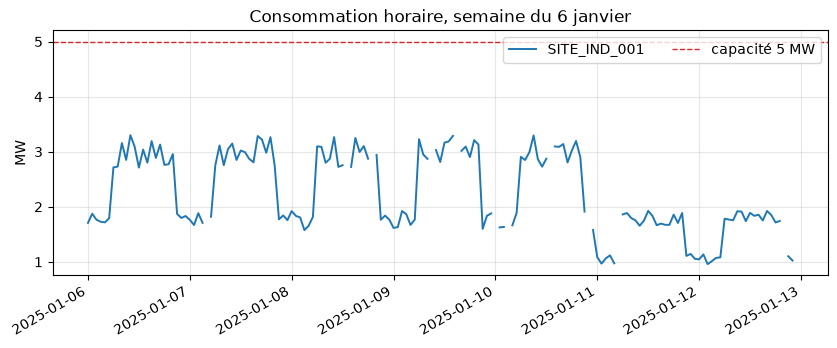

In [34]:
# === CELLULE 55 : Première courbe ===
Path("out").mkdir(exist_ok=True)

# Une semaine (6 au 12 janvier) d'un seul site
semaine = complet[(complet["site_id"] == "SITE_IND_001") & (complet["timestamp"] >= "2025-01-06") & (complet["timestamp"] < "2025-01-13")]

fig, ax = plt.subplots(figsize=(10, 3.6))                                   # la toile et le graphique
ax.plot(semaine["timestamp"], semaine["conso_mw"], color="#1f77b4", linewidth=1.4, label="SITE_IND_001")   # la courbe
ax.axhline(5.0, color="#d62728", linestyle="--", linewidth=1, label="capacité 5 MW")                        # ligne de capacité
ax.set_title("Consommation horaire, semaine du 6 janvier")
ax.set_ylabel("MW")
ax.legend(loc="upper right", ncol=2)                                        # légende sur 2 colonnes
ax.grid(alpha=0.3)                                                          # grille discrète
fig.autofmt_xdate()                                                         # dates inclinées, lisibles
fig.savefig("out/fig_courbe.png", dpi=110, bbox_inches="tight")

### Interpretation: Cell 55, matplotlib: figure, axis, curve

- **Week**: approximately 3 MW per day and 1.7 MW per night; **week-end** (11 and 12 January) is lower and flatter, from 1 to 1.9 MW.
- **Interruptions**:`NaN`are not traced.
- **Red line**: 5 MW capacity, never approached by this site.
- **Approche objet** : `fig`and`ax`give total control.

## 📝 Cellule 56 : Plusieurs graphiques : `subplots`and shared axes

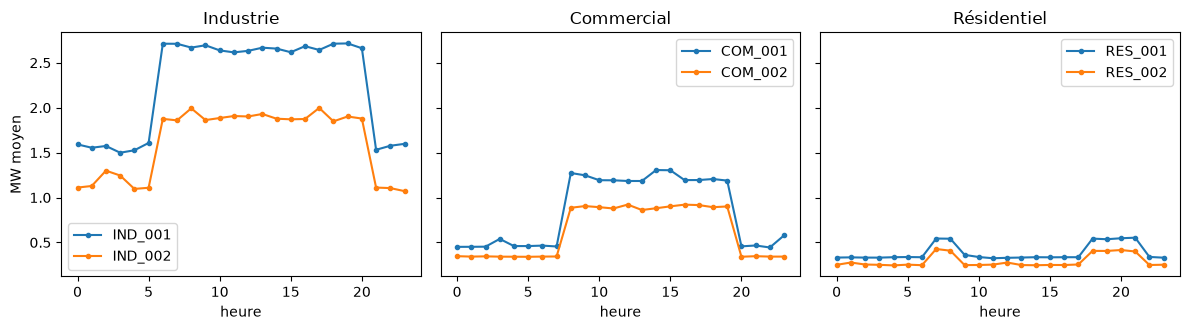

In [35]:
# === CELLULE 56 : Trois familles de sites ===

# --- 1. Les sites regroupés par famille
familles = {"Industrie": ["SITE_IND_001", "SITE_IND_002"],
            "Commercial": ["SITE_COM_001", "SITE_COM_002"],
            "Résidentiel": ["SITE_RES_001", "SITE_RES_002"]}

# --- 2. Trois graphiques côte à côte, avec la même échelle verticale
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, (nom, sites_famille) in zip(axes, familles.items()):        # un axe par famille
    for s in sites_famille:
        ax.plot(profil.index, profil[s], marker="o", markersize=3, label=s[-7:])   # une courbe par site (7 derniers caractères)
    ax.set_title(nom)
    ax.set_xlabel("heure")
    ax.legend()

# --- 3. Finitions : un seul libellé vertical, pas de chevauchement, enregistrement
axes[0].set_ylabel("MW moyen")
fig.tight_layout()
fig.savefig("out/fig_familles.png", dpi=110, bbox_inches="tight")

### Interpretation: Cell 56, Several graphs:`subplots`and shared axes

- **`sharey=True`**: common scale, so honest comparison between families.
- **Industry**: 1 to 2.7 MW; **residential**: less than 0.6 MW.
- **`axes[0].set_ylabel`**: only one text for three graphs.

## 📝 Cellule 57 : seaborn : `lineplot`with`hue`

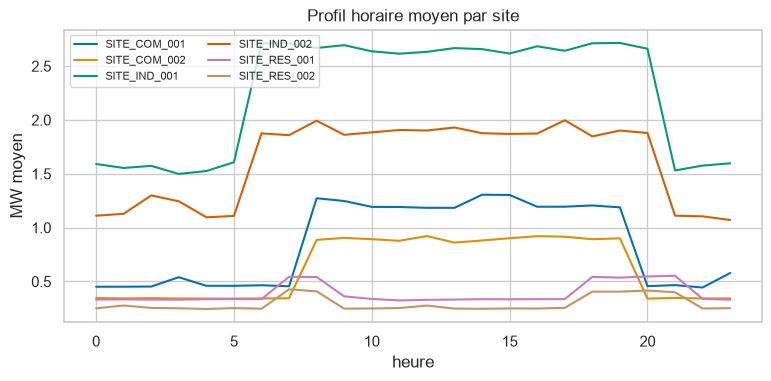

In [37]:
# === CELLULE 57 : lineplot ===
# --- 1. Style global : fond quadrillé et palette lisible pour les daltoniens (valable pour tous les graphiques suivants)
sns.set_theme(style="whitegrid", palette="colorblind")

# --- 2. Une courbe par site, à partir du DataFrame long
fig, ax = plt.subplots(figsize=(9, 3.8))
sns.lineplot(data=long, x="heure", y="mw_moyen", hue="site_id", ax=ax)   # x, y : colonnes ; hue : une couleur par site

# --- 3. Titres, légende et enregistrement
ax.set_title("Profil horaire moyen par site")
ax.set_ylabel("MW moyen")
ax.legend(title="", fontsize=8, ncol=2)               # légende sur 2 colonnes, sans titre
fig.savefig("out/fig_profils.png", dpi=110, bbox_inches="tight")

### Interpretation: Cell 57, seaborn:`lineplot`with`hue`

- **`hue="site_id"`** : one curve per site, without loop.
- **Two visible groups**: large sites at the top, two residential sites at the bottom.
- **Palette `colorblind`** : also readable for Daltonians.
- **Long format**: seaborn relies on the columns of the Long DataFrame.

## 📝 Cellule 58 : Distributions : `boxplot`and identification of anomalies

{'SITE_COM_001': 5, 'SITE_IND_002': 5, 'SITE_RES_002': 3, 'SITE_COM_002': 1, 'SITE_RES_001': 1}


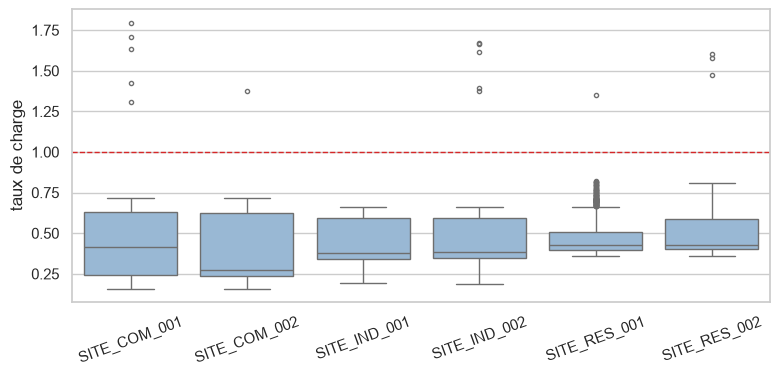

In [38]:
# === CELLULE 58 : boxplot ===
fig, ax = plt.subplots(figsize=(9, 3.8))
sns.boxplot(data=complet, x="site_id", y="taux_charge", ax=ax, color="#8fb8de", fliersize=3)   # une boîte par site
ax.axhline(1, color="#d62728", linestyle="--", linewidth=1)          # seuil de 100 % de la capacité
ax.set_ylabel("taux de charge")
ax.set_xlabel("")
ax.tick_params(axis="x", labelrotation=20)                           # noms des sites inclinés
fig.savefig("out/fig_boxplot.png", dpi=110, bbox_inches="tight")
print(complet.loc[complet["taux_charge"] > 1, "site_id"].value_counts().to_dict())    # dépassements par site

### Interpretation: Cell 58, Distributions:`boxplot`and identification of anomalies

- **Points above the red line**: the 15 aberrant peaks (`SITE_COM_001`and`SITE_IND_002` : 5 chacun).
- **Media**: from 0.27 to 0.43 capacity.
- **`SITE_RES_001`**: the cloud between 0.65 and 0.82 corresponds to the evening peaks, **normal**; Only the red line (1.0) reports an anomaly.
- **`SITE_IND_001`**: no overrun.

## 📝 Cellule 59 : Carte de chaleur : jour × heure

(30, 24)


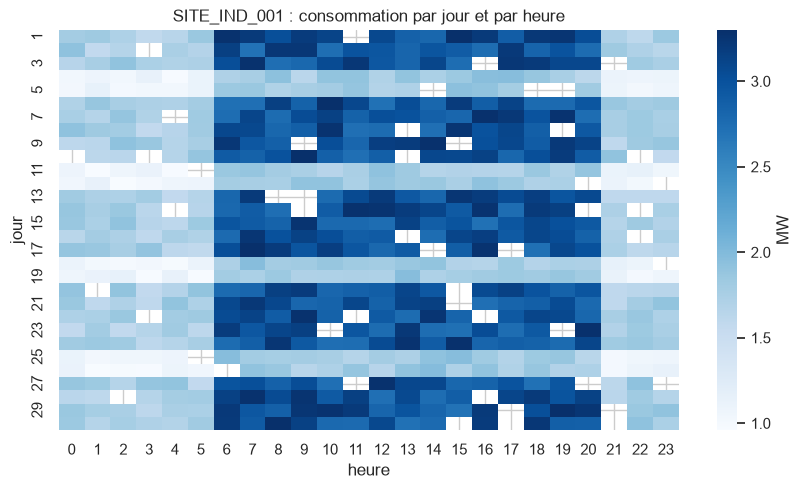

In [39]:
# === CELLULE 59 : heatmap ===

# --- 1. Un seul site, avec deux colonnes utiles : le jour du mois et l'heure
un_site = complet[complet["site_id"] == "SITE_IND_001"].assign(
    jour=lambda d: d["timestamp"].dt.day, heure=lambda d: d["timestamp"].dt.hour)

# --- 2. Tableau jours (lignes) x heures (colonnes), valeur = consommation moyenne
grille = un_site.pivot_table(index="jour", columns="heure", values="conso_mw", aggfunc="mean")

# --- 3. Une couleur par case ; les cases blanches sont des NaN
fig, ax = plt.subplots(figsize=(10, 5.2))
sns.heatmap(grille, cmap="Blues", cbar_kws={"label": "MW"}, ax=ax)
ax.set_title("SITE_IND_001 : consommation par jour et par heure")
fig.savefig("out/fig_heatmap.png", dpi=110, bbox_inches="tight")
print(grille.shape)                                  # (30 jours, 24 heures)

### Interpretation: Cell 59, Heat chart: day × hour

- **Cases blanches** : mesures manquantes (`NaN`).
- **Dark colour** from 6 a.m. to 8 p.m.: hours of activity.
- **Clearer lines**: weekends (4-5, 11-12, 18-19, 25-26 January).

## 📝 Cellule 60 : Histogramme par famille de sites

{'Commercial': 0.275, 'Industrie': 0.383, 'Residentiel': 0.429}


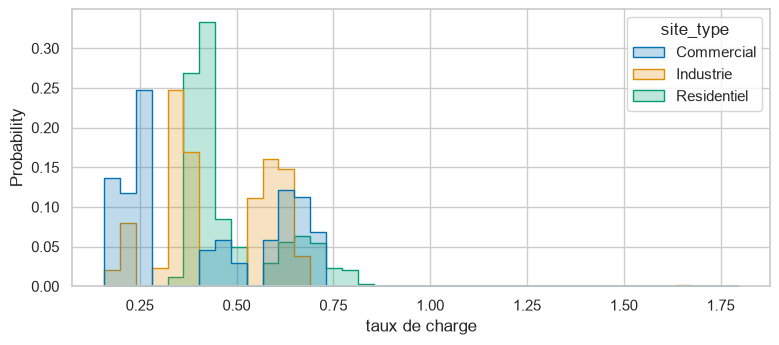

In [40]:
# === CELLULE 60 : histplot ===
fig, ax = plt.subplots(figsize=(9, 3.6))

# --- 1. Un histogramme par famille (hue) ; probability + common_norm=False : chaque famille ramenée à 100 %
sns.histplot(data=complet, x="taux_charge", hue="site_type", bins=40, element="step",
             stat="probability", common_norm=False, ax=ax)     # 40 tranches ; contours plutôt que barres pleines

# --- 2. Libellé et enregistrement
ax.set_xlabel("taux de charge")
fig.savefig("out/fig_histogramme.png", dpi=110, bbox_inches="tight")

# --- 3. Médiane du taux de charge par famille
print(complet.groupby("site_type", observed=True)["taux_charge"].median().round(3).to_dict())

### Interpretation: Cell 60, Histogram by Site Family

- **Median load rate**: commercial 0.275, industry 0.383, residential 0.429.
- **`common_norm=False`**: Each family is standardized separately.
- **`stat="probability"`** : compares families of different sizes.

## Cell 61: Export: CSV, Parquet and rereading

In [41]:
# === CELLULE 61 : Exports ===

# --- 1. Les colonnes utiles, écrites en CSV (lisible dans Excel) et en Parquet (typé et compressé)
final = complet[["timestamp", "site_id", "site_type", "conso_mw", "taux_charge", "niveau"]]
final.to_csv("out/mesures_propres.csv", index=False, encoding="utf-8-sig")     # index=False : sans numéros de ligne
final.to_parquet("out/mesures_propres.parquet", index=False)

# --- 2. Taille de chaque fichier
for nom in ("mesures_propres.csv", "mesures_propres.parquet"):
    print(f"{nom:<25} {Path('out', nom).stat().st_size / 1024:7.0f} Ko")

# --- 3. Relecture : quels types sont conservés ?
lu_csv = pd.read_csv("out/mesures_propres.csv", encoding="utf-8-sig")
lu_pq = pd.read_parquet("out/mesures_propres.parquet")
print(lu_csv["timestamp"].dtype, "|", lu_pq["timestamp"].dtype)     # texte contre datetime
print(lu_pq["niveau"].dtype)                                        # la catégorie est conservée

mesures_propres.csv           294 Ko
mesures_propres.parquet        41 Ko
object | datetime64[us]
category


### Interpretation: Cell 61, Export: CSV, Parquet and rereading

- **CSV** : 289 Ko ; **Parquet** : 41 Ko, environ 7 fois moins.
- **CSV relu** : `timestamp`becomes text again; **Parquet** preserved`datetime64`and`category`.
- **Parquet**: native Fabric and Delta format.
- **`pyarrow`** : installed for this reason in`venv-data`.

# PART 9: OF THE LOCAL POST IN FABRIC

The useful code leaves the notebook: you create the module ** by hand in the Windows Explorer**, then you import it.

## Manual step: Create module`qualite_pandas.py`

- ** Same approach** as`energie_utils.py`(Workshop 1): the useful code leaves the notebook for a reusable file.
- **Contenu** : `parser_dates`, `nettoyer`and`resume_sites`from Cells 42, 46 and 48.
- **Dependance**: the module requires **pandas**, so it only matters in`venv-data`.
- **Location**: next to the notebook, in the working file (Workshop 1, Cell 50: Python first searches in this folder).

1. Open folder`python_fabric_training`in the**Windows Explorer**.
2. View extensions: tab **View** → check **File name extensions**.
3. Right click in folder → **New** → **Text document**. Rename it **`qualite_pandas.py`** (confirm extension change).
4. Right click on file → **Open with** → **Bloc-notes**. Paste the contents below, then **Ctrl + S**.
5. Check encoding: **File → Save As → Encoding: UTF-8**.

In [42]:
# Étape manuelle : les apprenants créent ce fichier dans l'Explorateur ; ici, création automatique.
with open('qualite_pandas.py', 'w', encoding='utf-8') as f:
    f.write('"""qualite_pandas.py — Nettoyage des mesures EnergiaNord avec pandas (Workshop 2)."""\nimport pandas as pd\n\nCODES = (-999, -888, -777)\nFORMATS = ("%Y-%m-%dT%H:%M:%S", "%Y-%m-%d %H:%M:%S", "%d/%m/%Y %H:%M:%S")\n\n\ndef parser_dates(serie: pd.Series) -> pd.Series:\n    """Convertit des timestamps en 3 formats ; NaT si aucun format ne convient."""\n    resultat = pd.Series(pd.NaT, index=serie.index, dtype="datetime64[us]")\n    for fmt in FORMATS:\n        resultat = resultat.fillna(pd.to_datetime(serie, format=fmt, errors="coerce"))\n    return resultat\n\n\ndef nettoyer(brut: pd.DataFrame) -> pd.DataFrame:\n    """Doublons exacts, dates, codes erreur en NaN, tri par site et date."""\n    return (\n        brut\n        .drop_duplicates()\n        .assign(\n            timestamp=lambda d: parser_dates(d["timestamp"]),\n            conso_mw=lambda d: d["conso_mw"].mask(d["conso_mw"].isin(CODES)),\n        )\n        .sort_values(["site_id", "timestamp"], ignore_index=True)\n    )\n\n\ndef resume_sites(propre: pd.DataFrame) -> pd.DataFrame:\n    """Mesures, valides, taux d\'anomalies et consommation moyenne par site."""\n    return propre.groupby("site_id", observed=True).agg(\n        mesures=("conso_mw", "size"),\n        valides=("conso_mw", "count"),\n        moyenne_mw=("conso_mw", "mean"),\n    ).assign(taux_anomalies=lambda d: (1 - d["valides"] / d["mesures"]).round(3)).round(3)\n')
print('qualite_pandas.py', ':', len(open('qualite_pandas.py', encoding='utf-8').read().splitlines()), 'lignes')

qualite_pandas.py : 35 lignes


## Cell 62: Import and reuse the module

In [43]:
# === CELLULE 62 : Réutiliser qualite_pandas ===
import importlib, sys
from pathlib import Path

# --- 1. Le dossier de travail doit être dans sys.path, et le cache des dossiers rafraîchi
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
importlib.invalidate_caches()                     # le fichier vient d'être créé
print("qualite_pandas.py présent :", Path("qualite_pandas.py").exists(), "| dossier :", Path.cwd().name)   # doit afficher True

# --- 2. Importer votre module
import qualite_pandas as qp                       # votre module

# On repart du fichier brut, comme n'importe quel autre notebook
brut2 = pd.read_csv("data/consommation_30jours.csv", encoding="utf-8-sig").rename(columns={"consumption_mw": "conso_mw"})
propre2 = qp.nettoyer(brut2)                      # la fonction du module fait tout le nettoyage
print(qp.resume_sites(propre2))                   # tableau récapitulatif par site
print(len(propre2), "lignes | module :", qp.__name__)

qualite_pandas.py présent : True | dossier : python_fabric_training
              mesures  valides  moyenne_mw  taux_anomalies
site_id                                                   
SITE_COM_001      720      654       0.847           0.092
SITE_COM_002      720      669       0.617           0.071
SITE_IND_001      720      670       2.254           0.069
SITE_IND_002      720      658       1.613           0.086
SITE_RES_001      720      647       0.387           0.101
SITE_RES_002      720      672       0.293           0.067
4320 lignes | module : qualite_pandas


### Interpretation: Cell 62, Import and Reuse Module

- **Same figures** as Cell 47: 720 measurements per site, from 6.7% to 10.1% of anomalies.
- **4,320 lines** after cleaning.
- **Reuse**: Another notebook of the folder, with this kernel, imports it without copying anything.

## Cell 63: Envelop a DataFrame with   getattr  

In [44]:
# === CELLULE 63 : Un wrapper autour d'un DataFrame ===

# --- 1. La classe : un DataFrame à l'intérieur, une méthode métier à l'extérieur
class SuiviSite:
    def __init__(self, df):
        self._df = df                                     # le DataFrame enveloppé

    def __repr__(self):                                   # affichage court dans le notebook
        return f"SuiviSite({len(self)} mesures, {self._df['site_id'].nunique()} sites)"

    def __len__(self):
        return len(self._df)

    def __getitem__(self, cle):                           # suivi["conso_mw"], suivi[masque]... : délégué à pandas
        return self._df[cle]

    def __getattr__(self, nom):                           # appelée seulement si l'attribut n'existe pas ici
        if nom == "_df":                                  # évite une boucle infinie pendant la construction
            raise AttributeError(nom)
        return getattr(self._df, nom)                     # sinon : on demande au DataFrame

    def taux_anomalies(self):                             # méthode métier ajoutée par le wrapper
        return self._df["conso_mw"].isna().mean().round(3)

# --- 2. Utilisation sur le DataFrame nettoyé de la cellule précédente
suivi = SuiviSite(propre2)
print(suivi)                                              # __repr__
print(len(suivi), "|", suivi.shape)                       # __len__, puis .shape : délégué au DataFrame
print(suivi.taux_anomalies())                             # méthode du wrapper
print(suivi["conso_mw"].max())                            # __getitem__ délégué
print(suivi.head(2))                                      # .head() : jamais défini dans la classe

SuiviSite(4320 mesures, 6 sites)
4320 | (4320, 6)
0.081
5.846
            timestamp       site_id  conso_mw  voltage_v  frequency_hz status
0 2025-01-01 00:00:00  SITE_COM_001     0.458      234.8         49.87     OK
1 2025-01-01 01:00:00  SITE_COM_001       NaN      226.2         49.78  ERROR


### Interpretation: Cell 63, Enveloping a DataFrame with   getattr  

- **`suivi.shape`and`suivi.head()`** operate without writing:`__getattr__`transmit them to DataFrame.
- **`taux_anomalies()`** : the business logic lives in the class, pandas remains available below.
- **Actual use**: wrapper of a Reference DataFrame, or API client whose methods are delegated.

## Cell 64: A portable load: local and Fabric

In [34]:
# === CELLULE 64 : Chargement portable ===
from importlib.util import find_spec

# --- 1. Détecter l'environnement : notebookutils n'existe que dans Fabric
DANS_FABRIC = find_spec("notebookutils") is not None

# --- 2. Une seule fonction porte la différence entre les deux mondes
def charger_mesures(nom="consommation_30jours.csv") -> pd.DataFrame:
    # Dossier du Lakehouse dans Fabric, dossier data/ en local
    dossier = Path("/lakehouse/default/Files/data_python") if DANS_FABRIC else Path("data")
    # Le reste de la lecture est identique partout
    return pd.read_csv(dossier / nom, encoding="utf-8-sig").rename(columns={"consumption_mw": "conso_mw"})

# --- 3. Utilisation : le code appelant ne change pas
mesures = charger_mesures()
print(f"Dans Fabric : {DANS_FABRIC} | {len(mesures)} lignes | {len(qp.nettoyer(mesures))} après nettoyage")

Dans Fabric : False | 4365 lignes | 4320 après nettoyage


### Interpretation: Cell 64, A portable loading: local and Fabric

- **Local** : `DANS_FABRIC` vaut `False`, the reading aims`data/`.
- **In Fabric**: same function, Lakehouse Road`/lakehouse/default/Files/data_python/`.
- **Notebook Spark**: read with Spark, then`toPandas()`if the volume allows.
- **Isolate**: environmental differences in **one function**.